In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv('./dataGenerated/gurgaon_properties_missing_value_imputation.csv')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,722.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,East,661.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,East,1333.0,1,0,0,0,0,Relatively New,Unfurnished,49,4.20
4,flat,parkwood westend,sector 92,0.70,5204.0,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,East,1217.0,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


In [5]:
df.drop(columns=['areaWithType'],inplace=True)

In [6]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,2,2,1,1.0,West,722.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,2,2,3,12.0,East,661.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,2,2,2,2.0,East,1333.0,1,0,0,0,0,Relatively New,Unfurnished,49,4.20
4,flat,parkwood westend,sector 92,0.70,5204.0,2,2,3,5.0,East,1217.0,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


In [7]:
latlong=pd.read_csv('latlong.csv')

In [8]:
latlong.head()

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"


In [9]:
latlong['latitude']=latlong['coordinates'].str.split(',').str[0].str.split('°').str[0]

In [10]:
latlong['longitude']=latlong['coordinates'].str.split(',').str[1].str.split('°').str[0]

In [11]:
latlong

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176
5,sector 6,"28.4745° N, 77.0262° E",28.4745,77.0262
6,sector 7,"28.4644° N, 77.0143° E",28.4644,77.0143
7,sector 8,"28.3738° N, 76.8970° E",28.3738,76.8970
8,sector 9,"28.4603° N, 77.0000° E",28.4603,77.0000
9,sector 10,"28.4537° N, 77.0009° E",28.4537,77.0009


In [12]:
np.setdiff1d(df['sector'].unique(),latlong['sector'].unique()).tolist()

['dwarka expressway',
 'sector 3 phase 2',
 'sector 3 phase 3 extension',
 'sohna road',
 'sohna road road']

In [13]:
import pandas as pd

new_rows = pd.DataFrame({
    'sector': [
        'dwarka expressway',
        'sector 3 phase 2',
        'sector 3 phase 3 extension',
        'sohna road',
        'sohna road road'
    ],
    'coordinates': [
        '28.5206° N, 77.0235° E',
        '28.4873° N, 76.9872° E',
        '28.4908° N, 76.9935° E',
        '28.4223° N, 77.0402° E',
        '28.4223° N, 77.0402° E'
    ],
    'latitude': [
        28.5206,
        28.4873,
        28.4908,
        28.4223,
        28.4223
    ],
    'longitude': [
        77.0235,
        76.9872,
        76.9935,
        77.0402,
        77.0402
    ]
})

# Append to existing dataframe
latlong = pd.concat([latlong, new_rows], ignore_index=True)

# Optional: remove duplicates if any exist
latlong = latlong.drop_duplicates(subset='sector', keep='first').reset_index(drop=True)

print(latlong.tail())

                         sector             coordinates latitude longitude
129           dwarka expressway  28.5206° N, 77.0235° E  28.5206   77.0235
130            sector 3 phase 2  28.4873° N, 76.9872° E  28.4873   76.9872
131  sector 3 phase 3 extension  28.4908° N, 76.9935° E  28.4908   76.9935
132                  sohna road  28.4223° N, 77.0402° E  28.4223   77.0402
133             sohna road road  28.4223° N, 77.0402° E  28.4223   77.0402


In [14]:
df.shape

(3573, 20)

In [15]:
new_df=df.merge(latlong,on='sector')

In [16]:
new_df.shape

(3573, 23)

In [17]:
new_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,coordinates,latitude,longitude
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00,"28.4644° N, 77.0143° E",28.4644,77.0143
1,flat,apna enclave,sector 3,0.50,7692.0,2,2,1,1.0,West,722.0,0,0,0,0,0,Old Property,Furnished,14,4.25,"28.4909° N, 77.0176° E",28.4909,77.0176
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,2,2,3,12.0,East,661.0,0,0,0,0,0,New Property,Unfurnished,31,4.25,"28.4223° N, 77.0402° E",28.4223,77.0402
3,flat,smart world orchard,sector 61,1.47,12250.0,2,2,2,2.0,East,1333.0,1,0,0,0,0,Relatively New,Unfurnished,49,4.20,"28.4050° N, 77.0963° E",28.4050,77.0963
4,flat,parkwood westend,sector 92,0.70,5204.0,2,2,3,5.0,East,1217.0,1,0,0,0,0,Under Construction,Unfurnished,0,4.00,"28.4079° N, 76.9153° E",28.4079,76.9153


In [18]:
group_df=new_df[['sector','built_up_area','price_per_sqft','latitude','longitude']]

In [19]:
group_df.shape

(3573, 5)

In [20]:
group_df.head()

,sector,built_up_area,price_per_sqft,latitude,longitude
0,sector 7,1000.0,5000.0,28.4644,77.0143
1,sector 3,722.0,7692.0,28.4909,77.0176
2,sohna road,661.0,6723.0,28.4223,77.0402
3,sector 61,1333.0,12250.0,28.4050,77.0963
4,sector 92,1217.0,5204.0,28.4079,76.9153


In [21]:
group_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3573 entries, 0 to 3572
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sector          3573 non-null   str    
 1   built_up_area   3573 non-null   float64
 2   price_per_sqft  3573 non-null   float64
 3   latitude        3573 non-null   object 
 4   longitude       3573 non-null   object 
dtypes: float64(2), object(2), str(1)
memory usage: 171.9+ KB


In [22]:
group_df['latitude'] = pd.to_numeric(group_df['latitude'], errors='coerce')
group_df['longitude'] = pd.to_numeric(group_df['longitude'], errors='coerce')
group_df['price_per_sqft'] = pd.to_numeric(group_df['price_per_sqft'], errors='coerce')
group_df['built_up_area'] = pd.to_numeric(group_df['built_up_area'], errors='coerce')

In [23]:
group_df.head()

,sector,built_up_area,price_per_sqft,latitude,longitude
0,sector 7,1000.0,5000.0,28.4644,77.0143
1,sector 3,722.0,7692.0,28.4909,77.0176
2,sohna road,661.0,6723.0,28.4223,77.0402
3,sector 61,1333.0,12250.0,28.4050,77.0963
4,sector 92,1217.0,5204.0,28.4079,76.9153


In [27]:
fig = px.scatter_map(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  map_style="open-street-map",text=group_df.index)
fig.show()

In [25]:
!pip install -U nbformat


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
new_df.to_csv('dataviz1.csv',index=False)

In [28]:
# wordcloud

In [30]:
df1 = pd.read_csv('./dataGenerated/gurugram_properties.csv')

In [40]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,2 BHK Flat in Krishna Colony,flat,maa bhagwati residency,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,"Krishna Colony, Gurgaon, Haryana",4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...",So with lift.Maa bhagwati residency is one of ...,"['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...",[],"['Environment4 out of 5', 'Safety4 out of 5', ..."
1,2 BHK Flat in Ashok Vihar,flat,apna enclave,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not available,"46b, Ashok Vihar, Gurgaon, Haryana",1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","Property situated on main road, railway statio...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...",[],"['Environment4 out of 5', 'Safety4 out of 5', ..."
2,2 BHK Flat in Sohna,flat,tulsiani easy in homes,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not available,"Sohna, Gurgaon, Haryana",12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...","This property is 15 km away from badshapur, gu...",NaN,[],"['Environment4 out of 5', 'Safety4 out of 5', ..."
3,2 BHK Flat in Sector 61 Gurgaon,flat,smart world orchard,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,"Sector 61 Gurgaon, Gurgaon, Haryana",2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",Near to metro station of sector 56 and opposit...,NaN,[],NaN
4,2 BHK Flat in Sector 92 Gurgaon,flat,parkwood westend,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,"Sector 92 Gurgaon, Gurgaon, Haryana",5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",We are the proud owners of this 2 bhk alongwit...,[],[],"['Environment5 out of 5', 'Safety3 out of 5', ..."


In [41]:
# creating a new df with sector and festures

In [42]:
df_feat=pd.read_csv('./dataGenerated/gurugram_properties_cleaned_v1.csv')

In [45]:
df_feat.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...","['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ..."


In [50]:
df_feat=df_feat[['sector','features']]

In [51]:
df_feat.to_csv('dataviz2.csv',index=False)

In [52]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [53]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [54]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27288\3761596323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == 'house']['price'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27288\3761596323.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] 

<Axes: xlabel='price', ylabel='Density'>

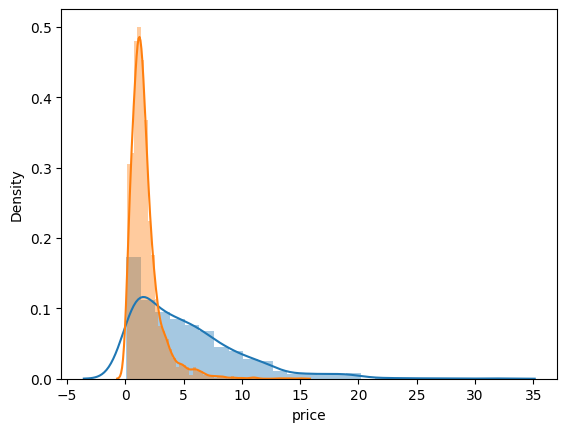

In [55]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])